## What are embeddings ?

#### Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

Plotting word: 'cat' at coordinates: [0.8, 0.6]
Plotting word: 'kitten' at coordinates: [0.75, 0.65]
Plotting word: 'dog' at coordinates: [0.7, 0.3]
Plotting word: 'puppy' at coordinates: [0.65, 0.35]
Plotting word: 'car' at coordinates: [-0.5, 0.2]
Plotting word: 'truck' at coordinates: [-0.45, 0.15]


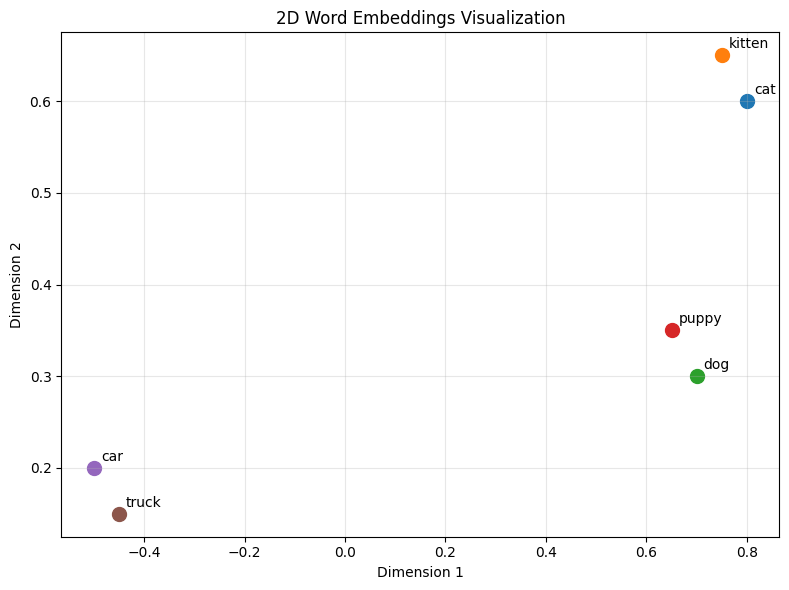

In [11]:
fig, ax = plt.subplots(figsize=(8, 6)) # Create a figure and axis for plotting
for word, coords in word_embeddings.items():
    print(f"Plotting word: '{word}' at coordinates: {coords}") # Debug statement to check coordinates
    ax.scatter(coords[0], coords[1], s=100) # Plot the word embedding as a point
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), textcoords='offset points') # Annotate the point with the word

ax.set_xlabel('Dimension 1') # Label for x-axis
ax.set_ylabel('Dimension 2') # Label for y-axis
ax.set_title('2D Word Embeddings Visualization') # Title for the plot
ax.grid(True, alpha=0.3) # Add a grid for better visibility

plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plot

### Measuring Similarity

In [12]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2) # Calculate the dot product of the two vectors
    norm_a=np.linalg.norm(vec1) # Calculate the magnitude (norm) of the first vector
    norm_b=np.linalg.norm(vec2) # Calculate the magnitude (norm) of the second vector
    return dot_product/(norm_a * norm_b) # Return the cosine similarity by dividing the dot product by the product of the norms

In [13]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [15]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

### Creating Your First Embeddings

In [ ]:
### Huggingface And OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [23]:
## Create your first embedding
text="Hello, I am learning about embeddings"
text_embedding=embeddings.embed_query(text) # Generate an embedding for a single piece of text
print(f"Text : '{text}'")
print(f"Embedding length: {len(text_embedding)}") 
print(text_embedding) 

Text : 'Hello, I am learning about embeddings'
Embedding length: 384
[-0.016661599278450012, -0.09771720319986343, 0.0019201452378183603, -0.0016135016921907663, 0.01404665783047676, 0.06083925440907478, 0.012283633463084698, 0.015745429322123528, 0.04093793034553528, -0.030124550685286522, 0.02626514993607998, 0.06559298932552338, 0.045701682567596436, 0.008897033520042896, -0.04620598629117012, 0.019462518393993378, 0.046773042529821396, 0.07357389479875565, -0.07927088439464569, -0.00660086702555418, -0.03383967652916908, -0.04663921520113945, 0.010644893161952496, -0.0967354103922844, 0.024105260148644447, -0.025332972407341003, -0.021411148831248283, 0.059114888310432434, 0.10023821890354156, -0.06024160608649254, 0.03970739245414734, -0.033746276050806046, -0.019574353471398354, 0.0662289634346962, -0.061764709651470184, 0.11689269542694092, 0.03955423831939697, -0.0030686173122376204, -0.08189611881971359, -0.0036541447043418884, 0.028080858290195465, 0.025156347081065178, -0.02

In [29]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences) # Generate embeddings for a list of sentences

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018646478653, -0.011870087124407291, -0.028117019683122635, 0.05123864486813545, -0.05597444996237755, 0.03019154816865921, 0.030161282047629356, 0.02469841204583645, -0.018370602279901505, 0.05876681208610535, -0.024953192099928856, 0.06015424430370331, 0.03983175382018089, 0.033230528235435486, -0.061311379075050354, -0.04937311261892319, -0.054863542318344116, -0.04007606580853462, 0.05642911046743393, 0.039156582206487656, -0.03473709523677826, -0.013247692957520485, 0.031966209411621094, -0.06349924206733704, -0.060178596526384354, 0.07823450118303299, -0.028303859755396843, -0.04744282364845276, 0.040359292179346085, -0.0066308933310210705, -0.0667409673333168, -0.0041913921013474464, -0.02531163953244686, 0.053341664373874664, 0.0174280796200037, -0.09792359918355942, 0.006061296910047531, -0.06524161994457245, 0.04557260498404503, 0.023641837760806084, 0.0765848383307457, -0.010264369659125805, -0.004076819866895676, -0.06232282146811485, 0.03370526805520058, 0.018661107

In [31]:
# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")

📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

